# Analisi PM10

#### Download librerie

In [189]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [190]:
pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

### Import dei dati

In [191]:
file_path = os.path.join("..", "data", "dati_centraline_bologna_storico.parquet")
df = pd.read_parquet(file_path)

In [192]:
df.head()

,cod_staz,agente,data_inizio,data_fine,valore,um
0,PORTA SAN FELICE,NO (MONOSSIDO DI AZOTO),2018-10-09 13:01:00+02:00,2018-10-09 14:00:00+02:00,12.0,ug/m3
1,PORTA SAN FELICE,NO (MONOSSIDO DI AZOTO),2018-10-11 21:01:00+02:00,2018-10-11 22:00:00+02:00,12.0,ug/m3
2,PORTA SAN FELICE,NO (MONOSSIDO DI AZOTO),2018-10-15 17:01:00+02:00,2018-10-15 18:00:00+02:00,12.0,ug/m3
3,PORTA SAN FELICE,NO (MONOSSIDO DI AZOTO),2018-10-18 22:01:00+02:00,2018-10-18 23:00:00+02:00,12.0,ug/m3
4,PORTA SAN FELICE,NO (MONOSSIDO DI AZOTO),2018-10-22 15:01:00+02:00,2018-10-22 16:00:00+02:00,12.0,ug/m3


In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 696683 entries, 0 to 696682
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype                      
---  ------       --------------   -----                      
 0   cod_staz     696683 non-null  str                        
 1   agente       696683 non-null  str                        
 2   data_inizio  696683 non-null  datetime64[ms, Europe/Rome]
 3   data_fine    696683 non-null  datetime64[ms, Europe/Rome]
 4   valore       696671 non-null  float64                    
 5   um           696683 non-null  str                        
dtypes: datetime64[ms, Europe/Rome](2), float64(1), str(3)
memory usage: 58.3 MB


#### Selezione degli anni e divisione in centraline

In [194]:
# seleziono i dati del 2024 e del 2025
df_filtrato = df[df['data_inizio'].dt.year.isin([2024, 2025])]

In [195]:
df_filtrato['cod_staz'].value_counts()

cod_staz
PORTA SAN FELICE       82475
GIARDINI MARGHERITA    35629
VIA CHIARINI           34700
Name: count, dtype: int64

In [196]:
df_SF = df_filtrato.loc[df_filtrato['cod_staz'] == 'PORTA SAN FELICE', :]

df_GM = df_filtrato.loc[df_filtrato['cod_staz'] == 'GIARDINI MARGHERITA', :]

df_VC = df_filtrato.loc[df_filtrato['cod_staz'] == 'VIA CHIARINI', :]

## Centraline

+ Ci accorgiamo che le osservazioni di PM10 sono giornaliere.
+ Togliamo le le date per ogni centralina in cui PM10 è missing
+ Raggruppo gli agenti in cui ho la misura oraria in modo da avere due valori per ogni giorno: la media (o mediana) e il max

### Centralina di VIA CHIARINI

#### Chek giorni e duplicati

In [197]:
# check dei duplicati
df_VC['flag_dupl'] = df_VC.duplicated(keep=False)
df_VC['flag_dupl'].value_counts()

flag_dupl
False    34700
Name: count, dtype: int64

In [198]:
# creazione della flag per i missing
df_VC['flag_pm10'] = (df_VC['agente'] == 'PM10') & (df_VC['valore'].notna())
df_VC['flag_pm10'].value_counts()

flag_pm10
False    34008
True       692
Name: count, dtype: int64

In [199]:
# df con i valori di PM10 non missing
df_pm10 = df_VC.loc[df_VC['agente'] == 'PM10', :]

In [200]:
# check che la differenza sia sempre un giorno: ci aggorgiamo che ci sono differenze nei giorni di marzo con il cambio d'ora
df_pm10['diff'] = df_pm10['data_fine'] - df_pm10['data_inizio']
df_pm10['diff'].value_counts()

diff
0 days 23:59:00    688
0 days 22:59:00      2
1 days 00:59:00      2
Name: count, dtype: int64

In [201]:
# creo la colonna giorno con solo il giorno
df_pm10['giorno'] = df_pm10['data_inizio'].dt.date

df_pm10[df_pm10.duplicated(subset=['giorno'], keep=False)]

# il 30 marzo che inizia alle 23, in realtà mi sta misurando il 31
# il 29 marzo che inizia alle 23, in realtà mi sta misurando il 30

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,diff,giorno
63679,VIA CHIARINI,PM10,2025-03-29 00:01:00+01:00,2025-03-29 23:00:00+01:00,8.0,ug/m3,False,True,0 days 22:59:00,2025-03-29
146098,VIA CHIARINI,PM10,2024-03-30 00:01:00+01:00,2024-03-30 23:00:00+01:00,81.0,ug/m3,False,True,0 days 22:59:00,2024-03-30
521089,VIA CHIARINI,PM10,2024-03-30 23:01:00+01:00,2024-04-01 00:00:00+02:00,124.0,ug/m3,False,True,0 days 23:59:00,2024-03-30
571219,VIA CHIARINI,PM10,2025-03-29 23:01:00+01:00,2025-03-31 00:00:00+02:00,3.0,ug/m3,False,True,0 days 23:59:00,2025-03-29


In [202]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_VC.loc[(df_VC['agente'] == 'PM10') & (df_VC['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_VC.loc[(df_VC['agente'] == 'PM10') & (df_VC['data_inizio'] == '2024-03-30 23:01:00+01:00	'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

# cambio i giorni che iniziano alle 23 ma sul df_SF
df_pm10.loc[(df_pm10['agente'] == 'PM10') & (df_pm10['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_pm10.loc[(df_pm10['agente'] == 'PM10') & (df_pm10['data_inizio'] == '2024-03-30 23:01:00+01:00	'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

# trasformo la data di inizio e di fine solamente in data del giorno
df_VC['giorno'] = df_VC['data_inizio'].dt.date
df_pm10['giorno'] = df_pm10['data_inizio'].dt.date

In [203]:
# check
df_check_giorno = df_VC.loc[df_VC['agente'] == 'PM10', 'giorno']
df_check_giorno.nunique()

692

#### Check e assemblaggio agenti misurati

In [204]:
df_VC['agente'].value_counts()

agente
O3 (OZONO)                 17101
NO2 (BIOSSIDO DI AZOTO)    16907
PM10                         692
Name: count, dtype: int64

In [205]:
len(df_pm10['giorno'])

692

In [206]:
# Selezione solo dei giorni in cui ho pm10

df_giorni = df_VC[df_VC['giorno'].isin(df_pm10['giorno'])]

In [207]:
# Check missing
df_giorni['valore'].isna().sum()

np.int64(0)

In [208]:
df_giorni['agente'].value_counts()

agente
O3 (OZONO)                 16245
NO2 (BIOSSIDO DI AZOTO)    16090
PM10                         692
Name: count, dtype: int64

#### O3 (OZONO)

In [209]:
# controllo se ci sono giorni con un numero di informazioni minori di 24
df_O3_VC = df_giorni.loc[(df_giorni['agente'] == 'O3 (OZONO)'), :]

df_O3_VC['data_inizio'] = pd.to_datetime(df_O3_VC['data_inizio'])
df_O3_VC['giorno'] = df_O3_VC['data_inizio'].dt.date
df_O3_VC['ora'] = df_O3_VC['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_O3_VC.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-02-21    23
2024-03-31    23
2024-04-15    22
2024-07-15    22
2024-07-31    22
Name: ora, dtype: int64


Per ora gestiamo questi dati escludendoli
Se abbiamo tempo ci torniamo

In [210]:
# check se ci sono duplicati di giorno e ora
duplicati = df_O3_VC.groupby(['giorno', 'ora']).size()
duplicati = duplicati[duplicati > 1]

print(duplicati)

giorno      ora
2024-03-31  3      2
2025-03-30  3      2
dtype: int64


In [211]:
df_O3_VC['giorno'] = pd.to_datetime(df_O3_VC['giorno'] )

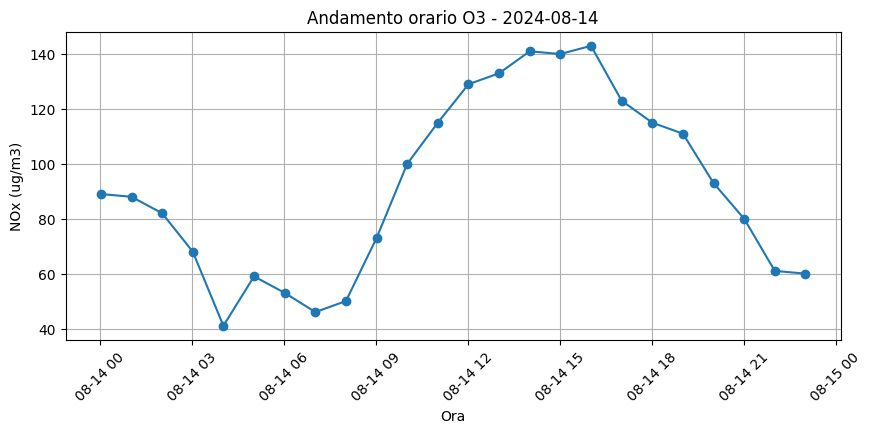

In [212]:
giorno = '2024-08-14'

df_day = df_O3_VC.loc[df_O3_VC['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')

plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario O3 - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Vedo l'andamento dell'agente in un singolo giorno.

Ora cerco nella letteratura se c'è un criterio per cui scegliere il massimo, la media o la mediana.

Sembra che si utilizzi sia la media giornaliera che dei limiti giornalieri da non superare.
Quindi decido prima di tutto di togliere gli outliers e poi di fare due variabili per ogni agente: una con la media e una con il massimo.

In [213]:
# check degli outliers con .describe
df_O3_VC['valore'].describe()

count    16245.000000
mean        42.668144
std         36.900828
min          0.000000
25%         12.000000
50%         34.000000
75%         64.000000
max        210.000000
Name: valore, dtype: float64

In [214]:
(df_O3_VC['valore'] == 0).sum()

np.int64(464)

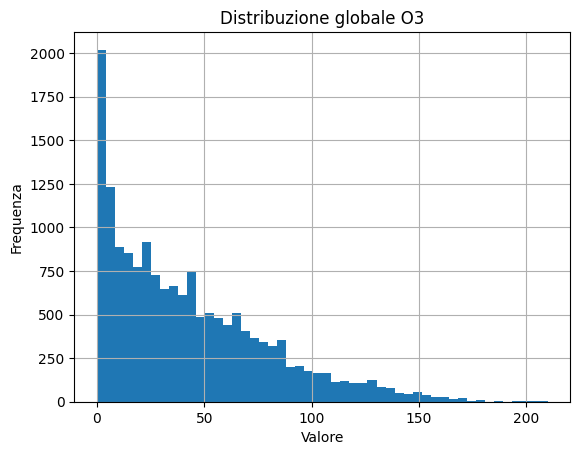

In [215]:
fig, o3_vc = plt.subplots()
df_O3_VC['valore'].hist(bins=50, ax=o3_vc)

o3_vc.set_title("Distribuzione globale O3")
o3_vc.set_xlabel("Valore")
o3_vc.set_ylabel("Frequenza")

plt.show()

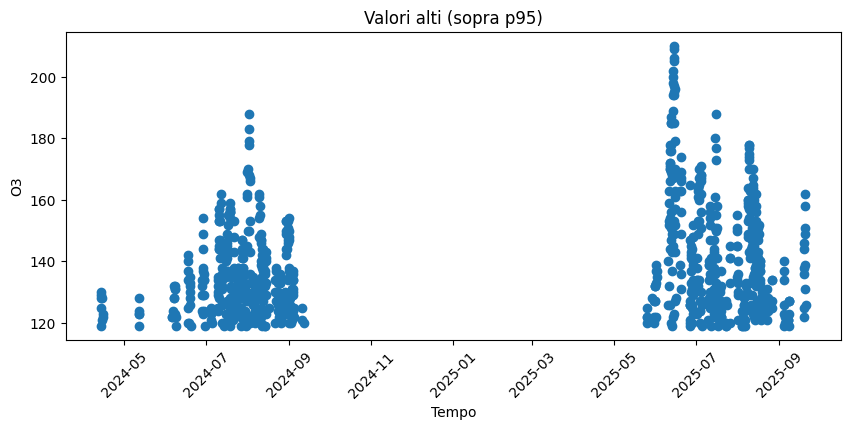

In [216]:
threshold = df_O3_VC['valore'].quantile(0.95)
df_high = df_O3_VC[df_O3_VC['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("O3")
plt.xticks(rotation=45)
plt.show()

Vedo che ci sono valori molto alti ma sono in estate, il che è coerente (link articolo)

Ci sono valori piuttosto alti ma decidiamo di tenerli perchè ci sembra che siano possibili.
Sono ricorrenti nei mesi invernali dove l'inquinamento aumenta quindi non sono così assurdi.

Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [217]:
df_o3_daily = (
    df_giorni[df_giorni['agente'] == 'O3 (OZONO)']
    .groupby('giorno')['valore']
    .agg(
        media_O3='mean',
        mediana_O3='median',
        massimo_O3='max'
    )
    .reset_index()
)

df_o3_daily['media_O3'] = df_o3_daily['media_O3'].round(2)

In [218]:
df_o3_daily.head()

,giorno,media_O3,mediana_O3,massimo_O3
0,2024-01-01,10.92,7.0,37.0
1,2024-01-02,2.46,1.5,8.0
2,2024-01-03,5.50,1.0,27.0
3,2024-01-04,13.33,3.0,60.0
4,2024-01-05,2.17,0.5,12.0


#### NO2 (BIOSSIDO DI AZOTO)

In [219]:
df_NO2_VC = df_giorni.loc[(df_giorni['agente'] == 'NO2 (BIOSSIDO DI AZOTO)'), :]

df_NO2_VC['data_inizio'] = pd.to_datetime(df_NO2_VC['data_inizio'])
df_NO2_VC['giorno'] = df_NO2_VC['data_inizio'].dt.date
df_NO2_VC['ora'] = df_NO2_VC['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_NO2_VC.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-02-21    22
2024-03-31    23
2024-05-01    23
2024-05-13    20
2024-06-26    22
Name: ora, dtype: int64


Per ora gestiamo questi dati escludendoli
Se abbiamo tempo ci torniamo

In [220]:
# check se ci sono duplicati di giorno e ora
duplicati = df_NO2_VC.groupby(['giorno', 'ora']).size()
len(duplicati[duplicati > 1])

1

In [221]:
df_NO2_VC['giorno'] = pd.to_datetime(df_NO2_VC['giorno'] )

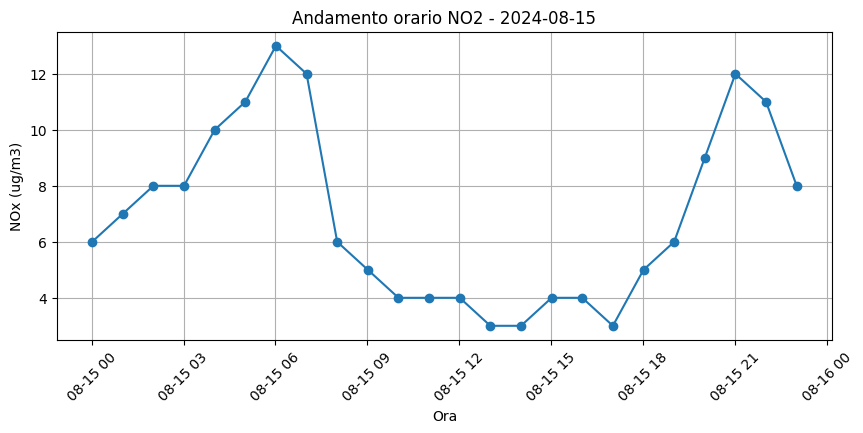

In [222]:
giorno = '2024-08-15'

df_day = df_NO2_VC.loc[df_NO2_VC['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')


plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario NO2 - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [223]:
# check degli outliers con .describe
df_NO2_VC['valore'].describe()

count    16090.000000
mean        16.011684
std         10.682822
min          0.000000
25%          8.000000
50%         14.000000
75%         22.000000
max         82.000000
Name: valore, dtype: float64

In [224]:
(df_NO2_VC['valore'] == 0).sum()

np.int64(60)

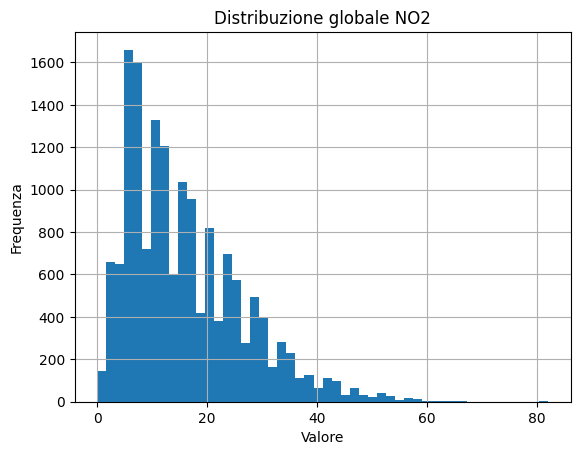

In [225]:
fig, no2_vc = plt.subplots()
df_NO2_VC['valore'].hist(bins=50, ax = no2_vc)

no2_vc.set_title("Distribuzione globale NO2")
no2_vc.set_xlabel("Valore")
no2_vc.set_ylabel("Frequenza")

plt.show()

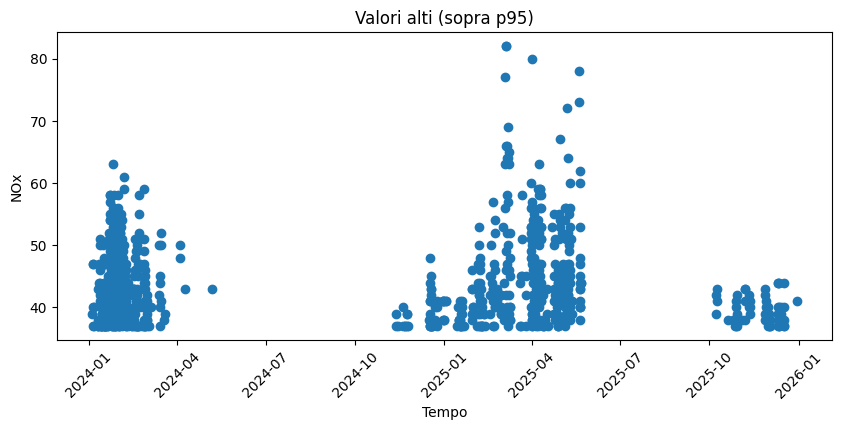

In [226]:
threshold = df_NO2_VC['valore'].quantile(0.95)
df_high = df_NO2_VC[df_NO2_VC['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("NOx")
plt.xticks(rotation=45)
plt.show()


Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [227]:
df_no2_daily = (
    df_giorni[df_giorni['agente'] == 'NO2 (BIOSSIDO DI AZOTO)']
    .groupby('giorno')['valore']
    .agg(
        media_NO2='mean',
        mediana_NO2='median',
        massimo_NO2='max'
    )
    .reset_index()
)

df_no2_daily['media_NO2'] = df_no2_daily['media_NO2'].round(2)

In [228]:
df_no2_daily.head()

,giorno,media_NO2,mediana_NO2,massimo_NO2
0,2024-01-01,20.00,20.5,26.0
1,2024-01-02,23.29,24.0,31.0
2,2024-01-03,26.67,26.0,32.0
3,2024-01-04,29.46,28.5,47.0
4,2024-01-05,29.38,29.5,40.0


#### Unisco tutti i df

In [229]:
df_aggregato = df_giorni.copy()

In [230]:
# tengo solo le righe con PM10

lista_agenti = ['O3 (OZONO)', 'NO2 (BIOSSIDO DI AZOTO)']

for age in lista_agenti:
    df_aggregato = df_aggregato.drop(df_aggregato[df_aggregato['agente'] == age].index)

In [231]:
# tolgo le colonne inutili

df_aggregato = df_aggregato.drop(['data_inizio', 'data_fine', 'um', 'flag_dupl', 'flag_pm10'], axis=1)

In [232]:
df_aggregato['agente'].value_counts()

agente
PM10    692
Name: count, dtype: int64

In [233]:
df_wide_pm10 = (
    df_aggregato[df_aggregato['agente'].isin(['PM10'])]
    .groupby(['giorno', 'agente'])['valore']
    .mean()
    .unstack()
)

df_wide_pm10 = df_wide_pm10.reset_index()

df_wide_pm10.shape

(692, 2)

In [234]:
df_wide_pm25 = (
    df_aggregato[df_aggregato['agente'].isin(['PM2.5'])]
    .groupby(['giorno', 'agente'])['valore']
    .mean()
    .unstack()
)

df_wide_pm25 = df_wide_pm25.reset_index()

df_wide_pm25.shape

(0, 1)

In [235]:
# faccio il merge con gli altri df

df_merge_VC = df_wide_pm10.merge(df_o3_daily, how = 'left', on = 'giorno')
df_merge_VC = df_merge_VC.merge(df_no2_daily, how='left', on = 'giorno')

df_merge_VC.shape

(692, 8)

In [236]:
df_merge_VC.isna().sum()

giorno          0
PM10            0
media_O3        7
mediana_O3      7
massimo_O3      7
media_NO2      12
mediana_NO2    12
massimo_NO2    12
dtype: int64

In [237]:
df_merge_VC.head()

,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2
0,2024-01-01,21.0,10.92,7.0,37.0,20.00,20.5,26.0
1,2024-01-02,21.0,2.46,1.5,8.0,23.29,24.0,31.0
2,2024-01-03,28.0,5.50,1.0,27.0,26.67,26.0,32.0
3,2024-01-04,25.0,13.33,3.0,60.0,29.46,28.5,47.0
4,2024-01-05,39.0,2.17,0.5,12.0,29.38,29.5,40.0


### Centralina di SAN FELICE

#### Check giorni e duplicati

In [238]:
df_SF['flag_dupl'] = df_SF.duplicated(keep=False)

In [239]:
df_SF['flag_dupl'].value_counts()

flag_dupl
False    82475
Name: count, dtype: int64

In [240]:
print(df_SF.shape)
print(df_GM.shape)
print(df_VC.shape)

(82475, 7)
(35629, 6)
(34700, 9)


Ci accorgiamo che le osservazioni di PM10 sono giornaliere.
Togliamo le osservazioni, quindi le date per ogni centralina, in cui in quella data non ho la misura di PM10
Poi raggruppo gli agenti in cui ho la misura oraria in modo da avere due valori per ogni giorno: la media (o mediana) e il max

In [241]:
# creo una flag per quando ho PM10
df_SF['flag_pm10'] = (df_SF['agente'] == 'PM10') & (df_SF['valore'].notna())
df_SF['flag_pm10'].value_counts()

# ho 706 osservazioni di PM10

flag_pm10
False    81769
True       706
Name: count, dtype: int64

In [242]:
# df solo per PM10 per capire,
df_pm10 = df_SF.loc[df_SF['agente'] == 'PM10', :]

In [243]:
# check che la differenza sia sempre un giorno

df_pm10['diff'] = df_pm10['data_fine'] - df_pm10['data_inizio']
df_pm10['diff'].value_counts()

diff
0 days 23:59:00    702
1 days 00:59:00      2
0 days 22:59:00      2
Name: count, dtype: int64

##### Nei giorni in cui c'è il cambio dell'ora ci sono dei bug, aggiorniamo manualmente le date di inizio e fine così che il valore registrato sia coerente con il giorno in cui è stato misurato

In [244]:
# creo la colonna giorno con solo il giorno
df_pm10['giorno'] = df_pm10['data_inizio'].dt.date

In [245]:
df_pm10[df_pm10.duplicated(subset=['giorno'], keep=False)]

# il 30 marzo che inizia alle 23, in realtà mi sta misurando il 31
# il 29 marzo che inizia alle 23, in realtà mi sta misurando il 30

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,diff,giorno
34872,PORTA SAN FELICE,PM10,2024-03-30 00:01:00+01:00,2024-03-30 23:00:00+01:00,96.0,ug/m3,False,True,0 days 22:59:00,2024-03-30
63988,PORTA SAN FELICE,PM10,2025-03-29 00:01:00+01:00,2025-03-29 23:00:00+01:00,15.0,ug/m3,False,True,0 days 22:59:00,2025-03-29
97976,PORTA SAN FELICE,PM10,2025-03-29 23:01:00+01:00,2025-03-31 00:00:00+02:00,15.0,ug/m3,False,True,0 days 23:59:00,2025-03-29
317130,PORTA SAN FELICE,PM10,2024-03-30 23:01:00+01:00,2024-04-01 00:00:00+02:00,129.0,ug/m3,False,True,0 days 23:59:00,2024-03-30


In [246]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_SF.loc[(df_SF['agente'] == 'PM10') & (df_SF['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_SF.loc[(df_SF['agente'] == 'PM10') & (df_SF['data_inizio'] == '2024-03-30 23:01:00+01:00'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [247]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_pm10.loc[(df_pm10['agente'] == 'PM10') & (df_pm10['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_pm10.loc[(df_pm10['agente'] == 'PM10') & (df_pm10['data_inizio'] == '2024-03-30 23:01:00+01:00'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [248]:
# trasformo la data di inizio e di fine solamente in data del giorno
df_SF['giorno'] = df_SF['data_inizio'].dt.date
df_pm10['giorno'] = df_pm10['data_inizio'].dt.date

In [249]:
df_check_giorno = df_SF.loc[df_SF['agente'] == 'PM10', 'giorno']
df_check_giorno.nunique()

706

#### Check e assemblaggio agenti misurati

In [250]:
df_SF['agente'].value_counts()

agente
NOX (OSSIDI DI AZOTO)         16663
CO (MONOSSIDO DI CARBONIO)    16653
NO2 (BIOSSIDO DI AZOTO)       16572
NO (MONOSSIDO DI AZOTO)       16175
C6H6 (BENZENE)                15016
PM10                            706
PM2.5                           690
Name: count, dtype: int64

#### PM 2.5

Si nota che tutti gli agenti tranne PM10 e PM2.5 sono misurati per ora, mentre i PM sono giornalieri

In [251]:
# aggiusto il pm 2.5 come il pm 10, vedo infatti che ci sono gli stessi bug
df_pm2_5 = df_SF.loc[df_SF['agente'] == 'PM2.5', :]

df_pm2_5['diff'] = df_pm2_5['data_fine'] - df_pm2_5['data_inizio']
df_pm2_5['diff'].value_counts()

diff
0 days 23:59:00    686
1 days 00:59:00      2
0 days 22:59:00      2
Name: count, dtype: int64

In [252]:
# vedo che i giorni sono esattamente8 gli stessi quindi basta cambibarli anche qui come prima
df_pm2_5['giorno'] = df_pm2_5['data_inizio'].dt.date
df_pm2_5[df_pm2_5.duplicated(subset=['giorno'], keep=False)]

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,giorno,diff
63775,PORTA SAN FELICE,PM2.5,2025-03-29 00:01:00+01:00,2025-03-29 23:00:00+01:00,5.0,ug/m3,False,False,2025-03-29,0 days 22:59:00
310675,PORTA SAN FELICE,PM2.5,2024-03-30 23:01:00+01:00,2024-04-01 00:00:00+02:00,28.0,ug/m3,False,False,2024-03-30,0 days 23:59:00
515240,PORTA SAN FELICE,PM2.5,2024-03-30 00:01:00+01:00,2024-03-30 23:00:00+01:00,18.0,ug/m3,False,False,2024-03-30,0 days 22:59:00
692095,PORTA SAN FELICE,PM2.5,2025-03-29 23:01:00+01:00,2025-03-31 00:00:00+02:00,5.0,ug/m3,False,False,2025-03-29,0 days 23:59:00


In [253]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_SF.loc[(df_SF['agente'] == 'PM2.5') & (df_SF['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_SF.loc[(df_SF['agente'] == 'PM2.5') & (df_SF['data_inizio'] == '2024-03-30 23:01:00+01:00'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [254]:
df_pm2_5.loc[(df_SF['agente'] == 'PM2.5') & (df_pm2_5['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_pm2_5.loc[(df_SF['agente'] == 'PM2.5') & (df_pm2_5['data_inizio'] == '2024-03-30 23:01:00+01:00'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [255]:
df_pm2_5['giorno'] = df_pm2_5['data_inizio'].dt.date

Prima devo recuperare la data di inizio con l ora.
Poi per ogni agente cerco di capire se è misurata a ora o a giorno.
Faccio pulizia e aggrego i dati che sono per ora.
faccio check che quelli per giorno non abbiano bug come lo aveva il PM10 a marzo.
Poi faccio il df unito.

In [256]:
df_SF['agente'].value_counts()

agente
NOX (OSSIDI DI AZOTO)         16663
CO (MONOSSIDO DI CARBONIO)    16653
NO2 (BIOSSIDO DI AZOTO)       16572
NO (MONOSSIDO DI AZOTO)       16175
C6H6 (BENZENE)                15016
PM10                            706
PM2.5                           690
Name: count, dtype: int64

In [257]:
df_SF.loc[df_SF['agente'] == 'NOX (OSSIDI DI AZOTO)', :]

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,giorno
23328,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2024-08-12 21:01:00+02:00,2024-08-12 22:00:00+02:00,67.0,ug/m3,False,False,2024-08-12
23329,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2024-08-12 22:01:00+02:00,2024-08-12 23:00:00+02:00,66.0,ug/m3,False,False,2024-08-12
23330,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2024-08-14 05:01:00+02:00,2024-08-14 06:00:00+02:00,80.0,ug/m3,False,False,2024-08-14
23331,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2024-08-14 12:01:00+02:00,2024-08-14 13:00:00+02:00,49.0,ug/m3,False,False,2024-08-14
23332,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2024-08-14 15:01:00+02:00,2024-08-14 16:00:00+02:00,40.0,ug/m3,False,False,2024-08-14
...,...,...,...,...,...,...,...,...,...
696664,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2025-02-19 11:01:00+01:00,2025-02-19 12:00:00+01:00,65.0,ug/m3,False,False,2025-02-19
696665,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2025-02-19 12:01:00+01:00,2025-02-19 13:00:00+01:00,70.0,ug/m3,False,False,2025-02-19
696666,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2025-02-20 22:01:00+01:00,2025-02-20 23:00:00+01:00,91.0,ug/m3,False,False,2025-02-20
696667,PORTA SAN FELICE,NOX (OSSIDI DI AZOTO),2025-02-22 05:01:00+01:00,2025-02-22 06:00:00+01:00,42.0,ug/m3,False,False,2025-02-22


Ora devo studiare e capire le altre variabili: come sono, come si distribuiscono e come potrei assemblarle

+ NOX (OSSIDI DI AZOTO)         16663
+ CO (MONOSSIDO DI CARBONIO)    16653
+ NO2 (BIOSSIDO DI AZOTO)       16572
+ NO (MONOSSIDO DI AZOTO)       16175
+ C6H6 (BENZENE)                15016

#### NOX (ossidi di azoto)

In [258]:
len(df_pm10['giorno'])

706

In [259]:
# teniamo solo i giorni in cui ho pm10

df_giorni = df_SF[df_SF['data_inizio'].dt.date.isin(df_pm10['giorno'])]

In [260]:
df_giorni.head(2)

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,giorno
23312,PORTA SAN FELICE,PM10,2024-08-15 00:01:00+02:00,2024-08-16 00:00:00+02:00,18.0,ug/m3,False,True,2024-08-15
23313,PORTA SAN FELICE,NO (MONOSSIDO DI AZOTO),2024-08-12 20:01:00+02:00,2024-08-12 21:00:00+02:00,15.0,ug/m3,False,False,2024-08-12


In [261]:
# controllo se ci sono giorni con un numero di informazioni minori di 24
df_OX_SF = df_giorni.loc[(df_giorni['agente'] == 'NOX (OSSIDI DI AZOTO)'), :]

df_OX_SF['data_inizio'] = pd.to_datetime(df_OX_SF['data_inizio'])
df_OX_SF['giorno'] = df_OX_SF['data_inizio'].dt.date
df_OX_SF['ora'] = df_OX_SF['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_OX_SF.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-16    23
2024-01-17    20
2024-01-18    22
2024-02-13    22
2024-02-15    20
Name: ora, dtype: int64


Dato che il numero di informazioni è comunque vicino a 24, decidiamo di tenerli e di trattarli come i giorni in cui abbiamo una misura per ora

In [262]:
# check se ci sono duplicati di giorno e ora
duplicati = df_OX_SF.groupby(['giorno', 'ora']).size()
duplicati = duplicati[duplicati > 1]

print(duplicati)

giorno      ora
2024-03-31  3      2
2025-09-08  19     2
            20     2
2025-09-09  8      2
dtype: int64


In [263]:
df_OX_SF['giorno'] = pd.to_datetime(df_OX_SF['giorno'] )


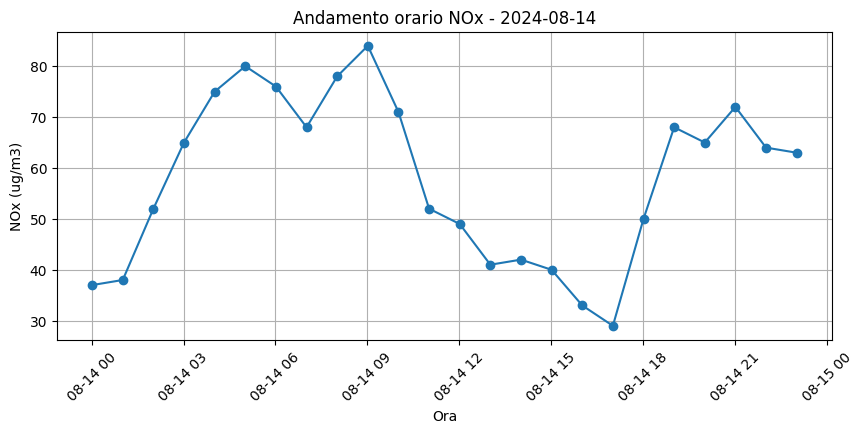

In [264]:
giorno = '2024-08-14'

df_day = df_OX_SF.loc[df_OX_SF['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')


plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario NOx - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Vedo l'andamento dell'agente in un singolo giorno.

Ora cerco nella letteratura se c'è un criterio per cui scegliere il massimo, la media o la mediana.

Sembra che si utilizzi sia la media giornaliera che dei limiti giornalieri da non superare.
Quindi decido prima di tutto di togliere gli outliers e poi di fare due variabili per ogni agente: una con la media e una con il massimo.

In [265]:
# check degli outliers con .describe
df_OX_SF['valore'].describe()

count    16352.000000
mean        55.946551
std         40.771576
min          0.000000
25%         28.000000
50%         46.000000
75%         72.000000
max        541.000000
Name: valore, dtype: float64

In [266]:
(df_OX_SF['valore'] == 0).sum()

np.int64(1)

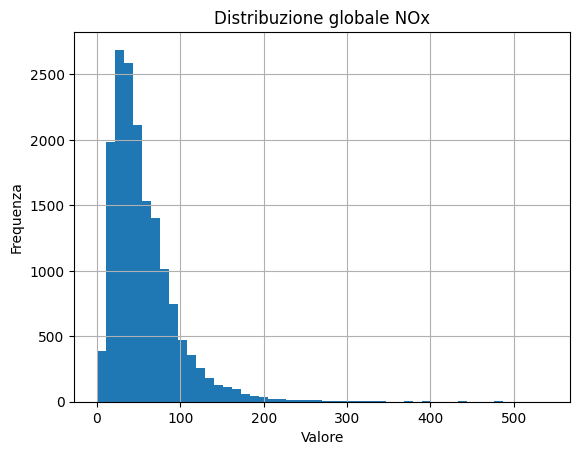

In [267]:
import matplotlib.pyplot as plt

df_OX_SF['valore'].hist(bins=50)
plt.title("Distribuzione globale NOx")
plt.xlabel("Valore")
plt.ylabel("Frequenza")
plt.show()

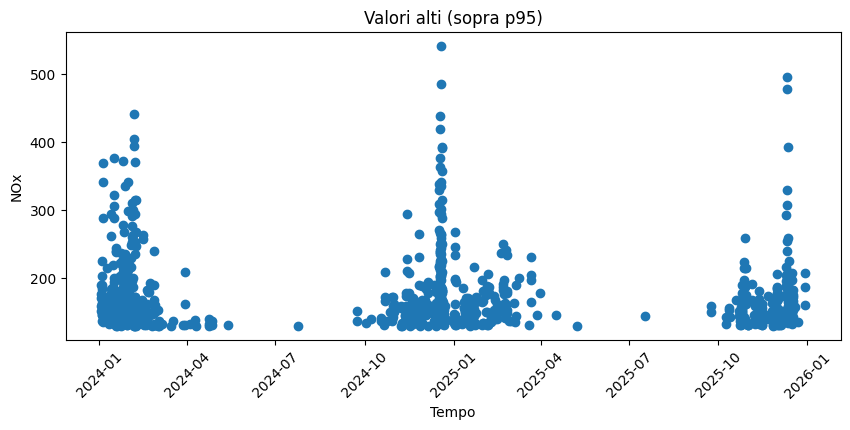

In [268]:
threshold = df_OX_SF['valore'].quantile(0.95)
df_high = df_OX_SF[df_OX_SF['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("NOx")
plt.xticks(rotation=45)
plt.show()

Ci sono valori piuttosto alti ma decidiamo di tenerli perchè ci sembra che siano possibili.
Sono ricorrenti nei mesi invernali dove l'inquinamento aumenta quindi non sono così assurdi.

Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [269]:
df_nox_daily = (
    df_giorni[df_giorni['agente'] == 'NOX (OSSIDI DI AZOTO)']
    .groupby('giorno')['valore']
    .agg(
        media_NOX='mean',
        mediana_NOX='median',
        massimo_NOX='max'
    )
    .reset_index()
)

df_nox_daily['media_NOX'] = df_nox_daily['media_NOX'].round(2)

In [270]:
df_nox_daily.head()

,giorno,media_NOX,mediana_NOX,massimo_NOX
0,2024-01-01,59.04,56.5,88.0
1,2024-01-02,94.62,89.5,190.0
2,2024-01-03,106.46,88.0,226.0
3,2024-01-04,134.79,107.0,370.0
4,2024-01-05,99.00,105.0,154.0


Ora lo faccio anche per le altre variabili, poi aggrego tutti i df insieme al PM10 e al PM2.5

#### CO (MONOSSIDO DI CARBONIO)

In [271]:
df_CO_SF = df_giorni.loc[(df_giorni['agente'] == 'CO (MONOSSIDO DI CARBONIO)'), :]

df_CO_SF['data_inizio'] = pd.to_datetime(df_CO_SF['data_inizio'])
df_CO_SF['giorno'] = df_CO_SF['data_inizio'].dt.date
df_CO_SF['ora'] = df_CO_SF['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_CO_SF.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-17    21
2024-03-31    23
2024-04-09    21
2024-05-09    20
2024-05-23    23
Name: ora, dtype: int64


Dato che il numero di informazioni è comunque vicino a 24, decidiamo di tenerli e di trattarli come i giorni in cui abbiamo una misura per ora

In [272]:
df_CO_SF['um'].unique()

<ArrowStringArray>
['mg/m3', 'ug/m3']
Length: 2, dtype: str

In [273]:
# ho um diverse quindi le trasformo

df_CO_SF.loc[df_CO_SF['um'] == 'mg/m3', 'valore'] *= 1000

In [274]:
# check se ci sono duplicati di giorno e ora
duplicati = df_CO_SF.groupby(['giorno', 'ora']).size()
len(duplicati[duplicati > 1])

216

In [275]:
df_CO_SF['giorno'] = pd.to_datetime(df_CO_SF['giorno'] )

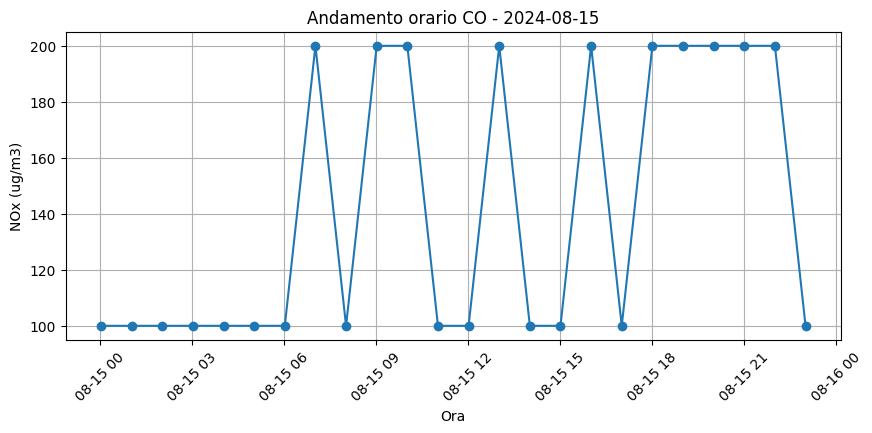

In [276]:
giorno = '2024-08-15'

df_day = df_CO_SF.loc[df_CO_SF['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario CO - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [277]:
# check degli outliers con .describe
df_CO_SF['valore'].describe()

count    16330.000000
mean       275.358224
std        345.900336
min          0.000000
25%          0.400000
50%        200.000000
75%        500.000000
max       2500.000000
Name: valore, dtype: float64

In [278]:
(df_CO_SF['valore'] == 0).sum()

np.int64(96)

Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [279]:
df_co_daily = (
    df_giorni[df_giorni['agente'] == 'CO (MONOSSIDO DI CARBONIO)']
    .groupby('giorno')['valore']
    .agg(
        media_CO='mean',
        mediana_CO='median',
        massimo_CO='max'
    )
    .reset_index()
)

df_co_daily['media_CO'] = df_co_daily['media_CO'].round(2)

In [280]:
df_co_daily.head()

,giorno,media_CO,mediana_CO,massimo_CO
0,2024-01-01,0.55,0.5,0.7
1,2024-01-02,0.66,0.6,1.0
2,2024-01-03,0.72,0.6,1.3
3,2024-01-04,0.82,0.7,2.2
4,2024-01-05,0.71,0.7,1.0


#### NO2 (BIOSSIDO DI AZOTO)

In [281]:
df_NO2_SF = df_giorni.loc[(df_giorni['agente'] == 'NO2 (BIOSSIDO DI AZOTO)'), :]

df_NO2_SF['data_inizio'] = pd.to_datetime(df_NO2_SF['data_inizio'])
df_NO2_SF['giorno'] = df_NO2_SF['data_inizio'].dt.date
df_NO2_SF['ora'] = df_NO2_SF['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_NO2_SF.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-16    23
2024-01-17    20
2024-01-18    22
2024-02-13    22
2024-02-15    20
Name: ora, dtype: int64


Dato che il numero di informazioni è comunque vicino a 24, decidiamo di tenerli e di trattarli come i giorni in cui abbiamo una misura per ora

In [282]:
# check se ci sono duplicati di giorno e ora
duplicati = df_NO2_SF.groupby(['giorno', 'ora']).size()
len(duplicati[duplicati > 1])

3

In [283]:
df_NO2_SF['giorno'] = pd.to_datetime(df_NO2_SF['giorno'] )

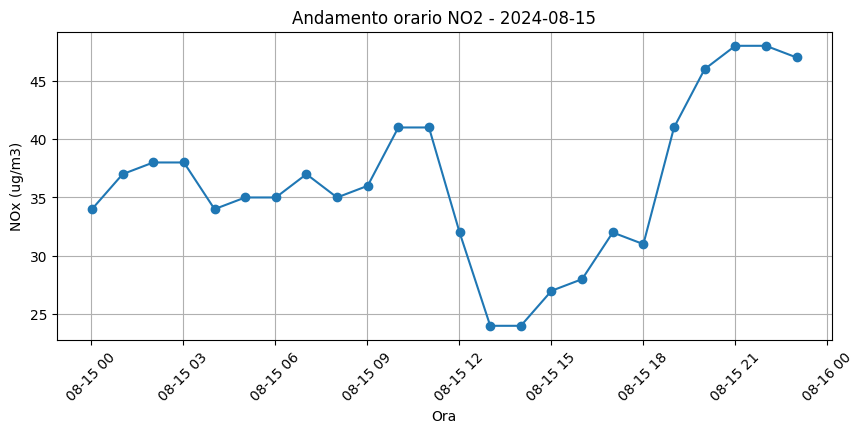

In [284]:
giorno = '2024-08-15'

df_day = df_NO2_SF.loc[df_NO2_SF['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')


plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario NO2 - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [285]:
# check degli outliers con .describe
df_NO2_SF['valore'].describe()

count    16309.000000
mean        30.031087
std         14.827678
min          2.000000
25%         19.000000
50%         28.000000
75%         39.000000
max        107.000000
Name: valore, dtype: float64

In [286]:
(df_NO2_SF['valore'] == 0).sum()

np.int64(0)

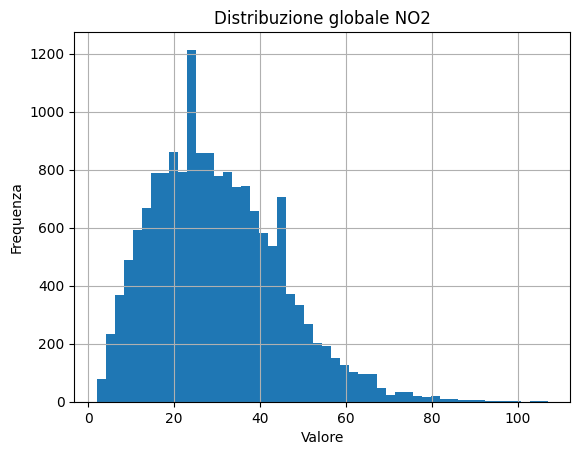

In [287]:
fig, no2_sf = plt.subplots()

df_NO2_SF['valore'].hist(bins=50, ax = no2_sf)

no2_sf.set_title("Distribuzione globale NO2")
no2_sf.set_xlabel("Valore")
no2_sf.set_ylabel("Frequenza")

plt.show()

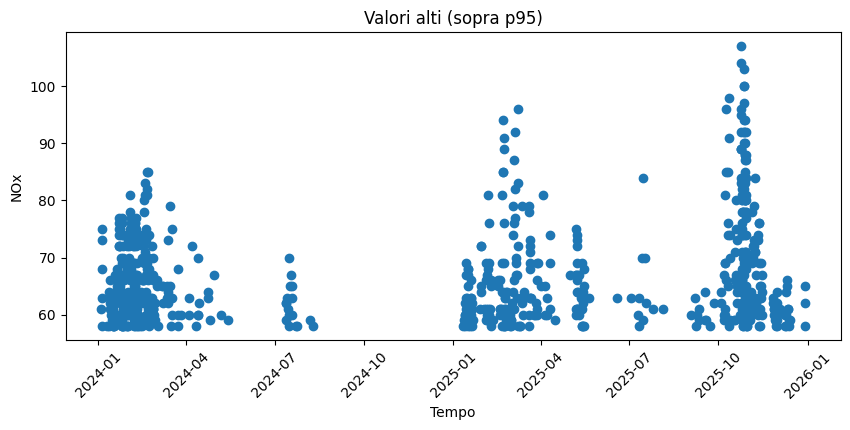

In [288]:
threshold = df_NO2_SF['valore'].quantile(0.95)
df_high = df_NO2_SF[df_NO2_SF['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("NOx")
plt.xticks(rotation=45)
plt.show()


Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [289]:
df_no2_daily = (
    df_giorni[df_giorni['agente'] == 'NO2 (BIOSSIDO DI AZOTO)']
    .groupby('giorno')['valore']
    .agg(
        media_NO2='mean',
        mediana_NO2='median',
        massimo_NO2='max'
    )
    .reset_index()
)

df_no2_daily['media_NO2'] = df_no2_daily['media_NO2'].round(2)

In [290]:
df_no2_daily.head()

,giorno,media_NO2,mediana_NO2,massimo_NO2
0,2024-01-01,28.71,27.0,39.0
1,2024-01-02,30.08,28.0,41.0
2,2024-01-03,38.58,35.5,61.0
3,2024-01-04,43.12,39.0,75.0
4,2024-01-05,34.46,34.0,44.0


#### NO (MONOSSIDO DI AZOTO)

In [291]:
df_NO_SF = df_giorni.loc[(df_giorni['agente'] == 'NO (MONOSSIDO DI AZOTO)'), :]

df_NO_SF['data_inizio'] = pd.to_datetime(df_NO_SF['data_inizio'])
df_NO_SF['giorno'] = df_NO_SF['data_inizio'].dt.date
df_NO_SF['ora'] = df_NO_SF['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_NO_SF.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-16    23
2024-01-17    20
2024-01-18    22
2024-02-13    22
2024-02-15    20
Name: ora, dtype: int64


Per ora gestiamo questi dati escludendoli
Se abbiamo tempo ci torniamo

In [292]:
# check se ci sono duplicati di giorno e ora
duplicati = df_NO_SF.groupby(['giorno', 'ora']).size()
len(duplicati[duplicati > 1])

4

In [293]:
df_NO_SF['giorno'] = pd.to_datetime(df_NO_SF['giorno'] )

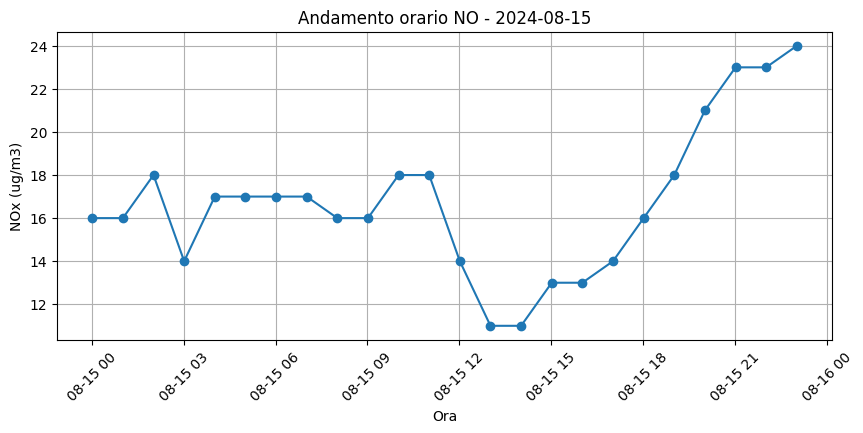

In [294]:
giorno = '2024-08-15'

df_day = df_NO_SF.loc[df_NO_SF['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')


plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario NO - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [295]:
# check degli outliers con .describe
df_NO_SF['valore'].describe()

count    15890.000000
mean        16.952926
std         21.047287
min         -1.000000
25%          4.000000
50%         11.000000
75%         21.000000
max        325.000000
Name: valore, dtype: float64

In [296]:
(df_NO_SF['valore'] == 0).sum()

np.int64(254)

Vedo che il minimo è negativo, ma non può essere quindi elimino quella osservazione

In [297]:
((df_NO_SF['valore'] < 0) == True).sum()

np.int64(2)

In [298]:
df_NO_SF = df_NO_SF.drop(df_NO_SF[df_NO_SF['valore'] == -1].index)

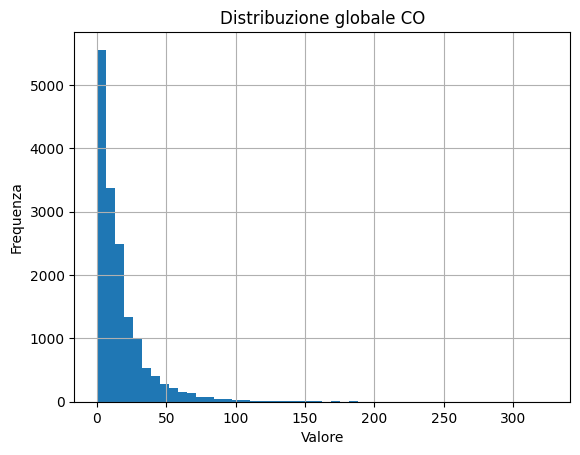

In [299]:

df_NO_SF['valore'].hist(bins=50)
plt.title("Distribuzione globale CO")
plt.xlabel("Valore")
plt.ylabel("Frequenza")
plt.show()

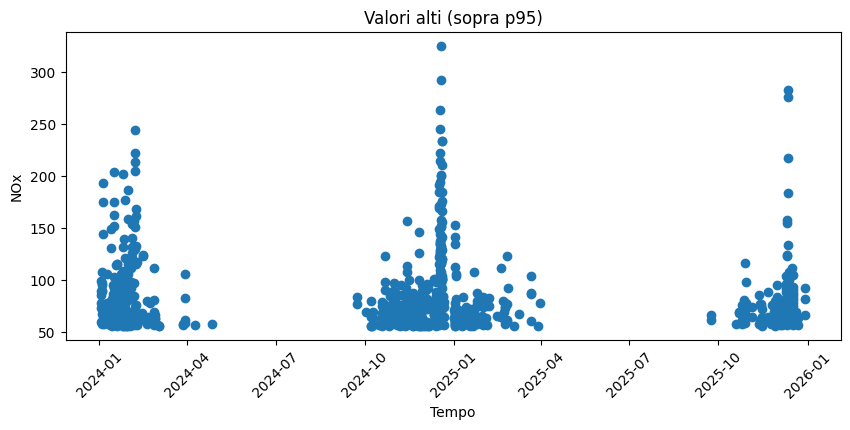

In [300]:
threshold = df_NO_SF['valore'].quantile(0.95)
df_high = df_NO_SF[df_NO_SF['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("NOx")
plt.xticks(rotation=45)
plt.show()

Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [301]:
df_no_daily = (
    df_giorni[df_giorni['agente'] == 'NO (MONOSSIDO DI AZOTO)']
    .groupby('giorno')['valore']
    .agg(
        media_NO='mean',
        mediana_NO='median',
        massimo_NO='max'
    )
    .reset_index()
)

df_no_daily['media_NO'] = df_no_daily['media_NO'].round(2)

In [302]:
df_no_daily.head()

,giorno,media_NO,mediana_NO,massimo_NO
0,2024-01-01,19.96,19.0,35.0
1,2024-01-02,42.21,40.5,99.0
2,2024-01-03,44.46,36.5,108.0
3,2024-01-04,60.08,42.5,193.0
4,2024-01-05,42.12,48.0,75.0


#### C6H6 (BENZENE)

In [303]:
df_C6H6_SF = df_giorni.loc[(df_giorni['agente'] == 'C6H6 (BENZENE)'), :]

df_C6H6_SF['data_inizio'] = pd.to_datetime(df_C6H6_SF['data_inizio'])
df_C6H6_SF['giorno'] = df_C6H6_SF['data_inizio'].dt.date
df_C6H6_SF['ora'] = df_C6H6_SF['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_C6H6_SF.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-01    23
2024-01-02    23
2024-01-03    23
2024-01-04    23
2024-01-05    23
Name: ora, dtype: int64


Dato che il numero di informazioni è comunque vicino a 24, decidiamo di tenerli e di trattarli come i giorni in cui abbiamo una misura per ora

In [304]:
# check se ci sono duplicati di giorno e ora
duplicati = df_C6H6_SF.groupby(['giorno', 'ora']).size()
len(duplicati[duplicati > 1])

1

In [305]:
df_C6H6_SF['giorno'] = pd.to_datetime(df_C6H6_SF['giorno'] )

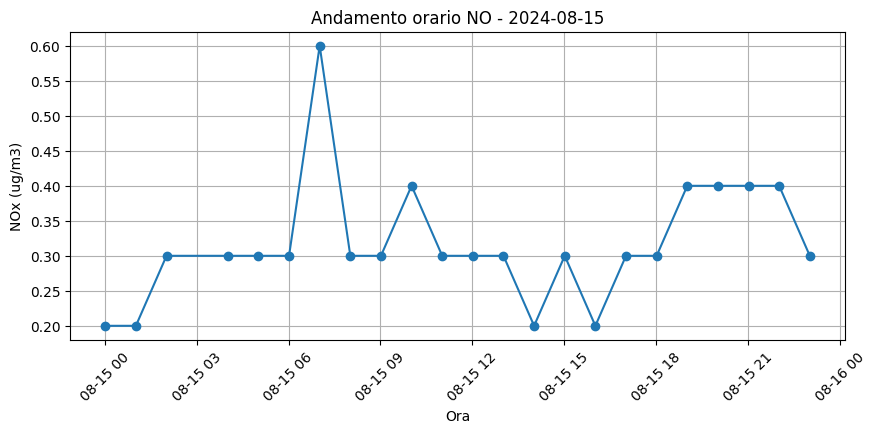

In [306]:
giorno = '2024-08-15'

df_day = df_C6H6_SF.loc[df_C6H6_SF['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')


plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario NO - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [307]:
# check degli outliers con .describe
df_C6H6_SF['valore'].describe()

count    14744.000000
mean         0.992282
std          0.702259
min          0.000000
25%          0.500000
50%          0.800000
75%          1.300000
max          6.100000
Name: valore, dtype: float64

In [308]:
(df_C6H6_SF['valore'] == 0).sum()

np.int64(22)

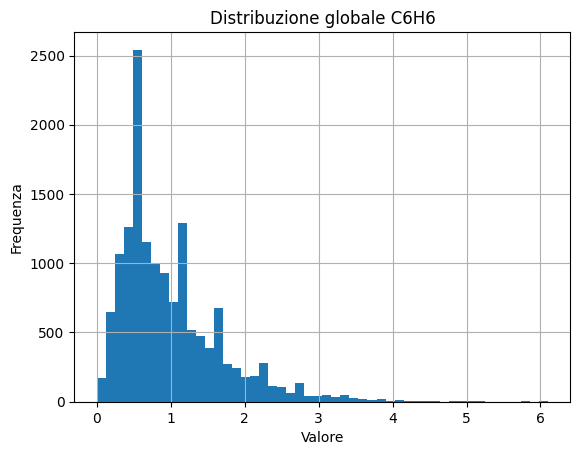

In [309]:

df_C6H6_SF['valore'].hist(bins=50)
plt.title("Distribuzione globale C6H6")
plt.xlabel("Valore")
plt.ylabel("Frequenza")
plt.show()

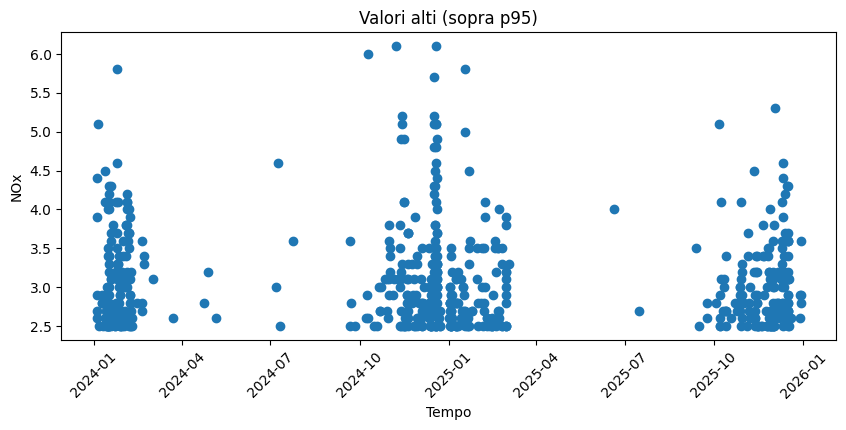

In [310]:
threshold = df_C6H6_SF['valore'].quantile(0.95)
df_high = df_C6H6_SF[df_C6H6_SF['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("NOx")
plt.xticks(rotation=45)
plt.show()

Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [311]:
df_c6h6_daily = (
    df_giorni[df_giorni['agente'] == 'C6H6 (BENZENE)']
    .groupby('giorno')['valore']
    .agg(
        media_C6H6='mean',
        mediana_C6H6='median',
        massimo_C6H6='max'
    )
    .reset_index()
)

df_c6h6_daily['media_C6H6'] = df_c6h6_daily['media_C6H6'].round(2)

In [312]:
df_c6h6_daily.head()

,giorno,media_C6H6,mediana_C6H6,massimo_C6H6
0,2024-01-01,1.37,1.2,1.8
1,2024-01-02,1.58,1.5,2.4
2,2024-01-03,1.67,1.5,2.9
3,2024-01-04,1.88,1.4,5.1
4,2024-01-05,1.72,1.7,2.5


#### Unisco tutti i df

In [313]:
df_aggregato = df_giorni.copy()

In [314]:
# tengo solo le righe con PM10 e PM2.5

lista_agenti = ['NOX (OSSIDI DI AZOTO)', 'CO (MONOSSIDO DI CARBONIO)', 'NO2 (BIOSSIDO DI AZOTO)',
                'NO (MONOSSIDO DI AZOTO)', 'C6H6 (BENZENE)']

for age in lista_agenti:
    df_aggregato = df_aggregato.drop(df_aggregato[df_aggregato['agente'] == age].index)

In [315]:
# tolgo le colonne inutili

df_aggregato = df_aggregato.drop(['data_inizio', 'data_fine', 'um', 'flag_dupl', 'flag_pm10'], axis=1)

In [316]:
df_wide_pm10 = (
    df_aggregato[df_aggregato['agente'].isin(['PM10'])]
    .groupby(['giorno', 'agente'])['valore']
    .mean()
    .unstack()
)

df_wide_pm10 = df_wide_pm10.reset_index()

df_wide_pm10.shape

(706, 2)

In [317]:
df_wide_pm25 = (
    df_aggregato[df_aggregato['agente'].isin(['PM2.5'])]
    .groupby(['giorno', 'agente'])['valore']
    .mean()
    .unstack()
)

df_wide_pm25 = df_wide_pm25.reset_index()

df_wide_pm25.shape

(680, 2)

In [318]:
# faccio il merge con gli altri df

df_wide = df_wide_pm10.merge(df_wide_pm25, how = 'left', on = 'giorno')
df_merge_SF = df_wide.merge(df_co_daily, how='left', on = 'giorno')
df_merge_SF = df_merge_SF.merge(df_nox_daily, how='left', on = 'giorno')
df_merge_SF = df_merge_SF.merge(df_no2_daily, how='left', on = 'giorno')
df_merge_SF = df_merge_SF.merge(df_no_daily, how='left', on = 'giorno')
df_merge_SF = df_merge_SF.merge(df_c6h6_daily, how='left', on = 'giorno')

df_merge_SF.shape

(706, 18)

In [319]:
df_merge_SF.isna().sum()

giorno           0
PM10             0
PM2.5           26
media_CO        23
mediana_CO      23
massimo_CO      23
media_NOX        6
mediana_NOX      6
massimo_NOX      6
media_NO2       13
mediana_NO2     13
massimo_NO2     13
media_NO        19
mediana_NO      19
massimo_NO      19
media_C6H6      53
mediana_C6H6    53
massimo_C6H6    53
dtype: int64

In [320]:
df_merge_SF.head()

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6
0,2024-01-01,24.0,19.0,0.55,0.5,0.7,59.04,56.5,88.0,28.71,27.0,39.0,19.96,19.0,35.0,1.37,1.2,1.8
1,2024-01-02,24.0,17.0,0.66,0.6,1.0,94.62,89.5,190.0,30.08,28.0,41.0,42.21,40.5,99.0,1.58,1.5,2.4
2,2024-01-03,32.0,23.0,0.72,0.6,1.3,106.46,88.0,226.0,38.58,35.5,61.0,44.46,36.5,108.0,1.67,1.5,2.9
3,2024-01-04,33.0,21.0,0.82,0.7,2.2,134.79,107.0,370.0,43.12,39.0,75.0,60.08,42.5,193.0,1.88,1.4,5.1
4,2024-01-05,39.0,30.0,0.71,0.7,1.0,99.00,105.0,154.0,34.46,34.0,44.0,42.12,48.0,75.0,1.72,1.7,2.5


### Centralina dei GIARDINI MARGHERITA

#### Check giorni e duplicati

In [321]:
df_GM['flag_dupl'] = df_GM.duplicated(keep=False)

In [322]:
df_GM['flag_dupl'].value_counts()

flag_dupl
False    35629
Name: count, dtype: int64

Ci accorgiamo che le osservazioni di PM10 sono giornaliere.
Togliamo le osservazioni, quindi le date per ogni centralina, in cui in quella data non ho la misura di PM10
Poi raggruppo gli agenti in cui ho la misura oraria in modo da avere due valori per ogni giorno: la media (o mediana) e il max

In [323]:
# creo una flag per quando ho PM10
df_GM['flag_pm10'] = (df_GM['agente'] == 'PM10') & (df_GM['valore'].notna())
df_GM['flag_pm10'].value_counts()

# ho 692 osservazioni di PM10

flag_pm10
False    34937
True       692
Name: count, dtype: int64

In [324]:
# df solo per PM10 per capire,
df_pm10 = df_GM.loc[df_GM['agente'] == 'PM10', :]

In [325]:
# check che la differenza sia sempre un giorno

df_pm10['diff'] = df_pm10['data_fine'] - df_pm10['data_inizio']
df_pm10['diff'].value_counts()

diff
0 days 23:59:00    688
1 days 00:59:00      2
0 days 22:59:00      2
Name: count, dtype: int64

##### Stesso ragionamento di prima per i giorni in cui c'è il cambio dell'ora


In [326]:
# creo la colonna giorno con solo il giorno
df_pm10['giorno'] = df_pm10['data_inizio'].dt.date

In [327]:
df_pm10[df_pm10.duplicated(subset=['giorno'], keep=False)]

# il 30 marzo che inizia alle 23, in realtà mi sta misurando il 31
# il 29 marzo che inizia alle 23, in realtà mi sta misurando il 30

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,diff,giorno
96304,GIARDINI MARGHERITA,PM10,2025-03-29 23:01:00+01:00,2025-03-31 00:00:00+02:00,7.0,ug/m3,False,True,0 days 23:59:00,2025-03-29
310677,GIARDINI MARGHERITA,PM10,2024-03-30 23:01:00+01:00,2024-04-01 00:00:00+02:00,113.0,ug/m3,False,True,0 days 23:59:00,2024-03-30
317106,GIARDINI MARGHERITA,PM10,2024-03-30 00:01:00+01:00,2024-03-30 23:00:00+01:00,84.0,ug/m3,False,True,0 days 22:59:00,2024-03-30
387391,GIARDINI MARGHERITA,PM10,2025-03-29 00:01:00+01:00,2025-03-29 23:00:00+01:00,17.0,ug/m3,False,True,0 days 22:59:00,2025-03-29


In [328]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_GM.loc[(df_GM['agente'] == 'PM10') & (df_GM['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_GM.loc[(df_GM['agente'] == 'PM10') & (df_GM['data_inizio'] == '2024-03-30 23:01:00+01:00	'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [329]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_pm10.loc[(df_pm10['agente'] == 'PM10') & (df_pm10['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_pm10.loc[(df_pm10['agente'] == 'PM10') & (df_pm10['data_inizio'] == '2024-03-30 23:01:00+01:00	'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

#### Check e assemblaggio agenti misurati

In [330]:
df_GM['agente'].value_counts()

agente
O3 (OZONO)                 17112
NO2 (BIOSSIDO DI AZOTO)    17108
PM2.5                        717
PM10                         692
Name: count, dtype: int64

In [331]:
# trasformo la data di inizio e di fine solamente in data del giorno
df_GM['giorno'] = df_GM['data_inizio'].dt.date
df_pm10['giorno'] = df_pm10['data_inizio'].dt.date

In [332]:
df_check_giorno = df_GM.loc[df_GM['agente'] == 'PM10', 'giorno']
df_check_giorno.nunique()

692

Cerco di capire quali agenti sono stati misurati a ora e quali a giorno

In [333]:
df_GM['agente'].value_counts()

agente
O3 (OZONO)                 17112
NO2 (BIOSSIDO DI AZOTO)    17108
PM2.5                        717
PM10                         692
Name: count, dtype: int64

Ora devo studiare e capire le altre variabili: come sono, come si distribuiscono e come potrei assemblarle

In [334]:
len(df_pm10['giorno'])

692

In [335]:
# teniamo solo i giorni in cui ho pm10

df_giorni = df_GM[df_GM['giorno'].isin(df_pm10['giorno'])]

In [336]:
df_giorni['agente'].value_counts()

agente
NO2 (BIOSSIDO DI AZOTO)    16336
O3 (OZONO)                 16290
PM10                         692
PM2.5                        685
Name: count, dtype: int64

#### PM 2.5

Si nota che tutti gli agenti tranne PM10 e PM2.5 sono misurati per ora, mentre i PM sono giornalieri

In [337]:
# aggiusto il pm 2.5 come il pm 10, vedo infatti che ci sono gli stessi bug
df_pm2_5 = df_GM.loc[df_GM['agente'] == 'PM2.5', :]

df_pm2_5['diff'] = df_pm2_5['data_fine'] - df_pm2_5['data_inizio']
df_pm2_5['diff'].value_counts()

diff
0 days 23:59:00    713
1 days 00:59:00      2
0 days 22:59:00      2
Name: count, dtype: int64

In [338]:
# vedo che i giorni sono esattamente8 gli stessi quindi basta cambibarli anche qui come prima
df_pm2_5['giorno'] = df_pm2_5['data_inizio'].dt.date
df_pm2_5[df_pm2_5.duplicated(subset=['giorno'], keep=False)]

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,giorno,diff
30661,GIARDINI MARGHERITA,PM2.5,2024-03-30 23:01:00+01:00,2024-04-01 00:00:00+02:00,46.0,ug/m3,False,False,2024-03-30,0 days 23:59:00
33340,GIARDINI MARGHERITA,PM2.5,2024-01-26 00:01:00+01:00,2024-01-27 00:00:00+01:00,56.0,ug/m3,False,False,2024-01-26,0 days 23:59:00
41319,GIARDINI MARGHERITA,PM2.5,2024-01-27 00:01:00+01:00,2024-01-28 00:00:00+01:00,42.0,ug/m3,False,False,2024-01-27,0 days 23:59:00
41323,GIARDINI MARGHERITA,PM2.5,2024-01-27 00:01:00+01:00,2024-01-28 00:00:00+01:00,45.0,ug/m3,False,False,2024-01-27,0 days 23:59:00
239162,GIARDINI MARGHERITA,PM2.5,2024-02-17 00:01:00+01:00,2024-02-18 00:00:00+01:00,57.0,ug/m3,False,False,2024-02-17,0 days 23:59:00
316277,GIARDINI MARGHERITA,PM2.5,2024-02-24 00:01:00+01:00,2024-02-25 00:00:00+01:00,3.0,ug/m3,False,False,2024-02-24,0 days 23:59:00
318277,GIARDINI MARGHERITA,PM2.5,2024-05-20 00:01:00+02:00,2024-05-21 00:00:00+02:00,17.0,ug/m3,False,False,2024-05-20,0 days 23:59:00
318745,GIARDINI MARGHERITA,PM2.5,2024-05-20 00:01:00+02:00,2024-05-21 00:00:00+02:00,16.0,ug/m3,False,False,2024-05-20,0 days 23:59:00
395112,GIARDINI MARGHERITA,PM2.5,2025-03-29 23:01:00+01:00,2025-03-31 00:00:00+02:00,4.0,ug/m3,False,False,2025-03-29,0 days 23:59:00
514222,GIARDINI MARGHERITA,PM2.5,2024-02-17 00:01:00+01:00,2024-02-18 00:00:00+01:00,77.0,ug/m3,False,False,2024-02-17,0 days 23:59:00


In [339]:
# cambio i giorni che iniziano alle 23 ma sul df_SF
df_GM.loc[(df_GM['agente'] == 'PM2.5') & (df_GM['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_GM.loc[(df_GM['agente'] == 'PM2.5') & (df_GM['data_inizio'] == '2024-03-30 23:01:00+01:00'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [340]:
df_pm2_5.loc[(df_SF['agente'] == 'PM2.5') & (df_pm2_5['data_inizio'] == '2025-03-29 23:01:00+01:00'), 'data_inizio'] = '2025-03-30 00:01:00+01:00'
df_pm2_5.loc[(df_SF['agente'] == 'PM2.5') & (df_pm2_5['data_inizio'] == '2024-03-30 23:01:00+01:00'), 'data_inizio'] = '2024-03-31 00:01:00+01:00'

In [341]:
df_pm2_5['giorno'] = df_pm2_5['data_inizio'].dt.date
df_GM['giorno'] = df_GM['data_inizio'].dt.date

Prima devo recuperare la data di inizio con l ora.
Poi per ogni agente cerco di capire se è misurata a ora o a giorno.
Faccio pulizia e aggrego i dati che sono per ora.
faccio check che quelli per giorno non abbiano bug come lo aveva il PM10 a marzo.
Poi faccio il df unito.

In [342]:
df_GM['agente'].value_counts()

agente
O3 (OZONO)                 17112
NO2 (BIOSSIDO DI AZOTO)    17108
PM2.5                        717
PM10                         692
Name: count, dtype: int64

#### O3 (OZONO)

In [343]:
# controllo se ci sono giorni con un numero di informazioni minori di 24
df_O3_GM = df_giorni.loc[(df_giorni['agente'] == 'O3 (OZONO)'), :]

df_O3_GM['data_inizio'] = pd.to_datetime(df_O3_GM['data_inizio'])
df_O3_GM['giorno'] = df_O3_GM['data_inizio'].dt.date
df_O3_GM['ora'] = df_O3_GM['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_O3_GM.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-17    22
2024-03-03    18
2024-03-28    23
2024-03-31    23
2024-04-08    20
Name: ora, dtype: int64


Dato che il numero di informazioni è comunque vicino a 24, decidiamo di tenerli e di trattarli come i giorni in cui abbiamo una misura per ora

In [344]:
# check se ci sono duplicati di giorno e ora
duplicati = df_O3_GM.groupby(['giorno', 'ora']).size()
duplicati = duplicati[duplicati > 1]

print(duplicati)

giorno      ora
2024-03-31  3      2
2025-03-30  3      2
dtype: int64


In [345]:
df_O3_GM['giorno'] = pd.to_datetime(df_O3_GM['giorno'] )

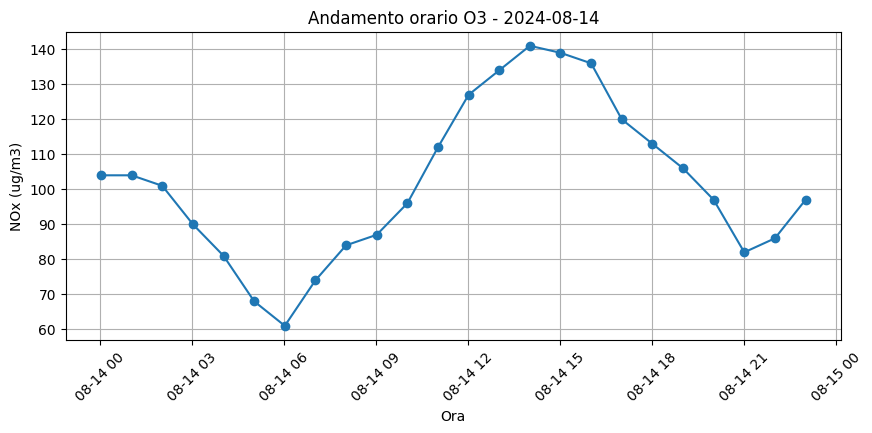

In [346]:
giorno = '2024-08-14'

df_day = df_O3_GM.loc[df_O3_GM['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')


plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario O3 - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Vedo l'andamento dell'agente in un singolo giorno.

Ora cerco nella letteratura se c'è un criterio per cui scegliere il massimo, la media o la mediana.

Sembra che si utilizzi sia la media giornaliera che dei limiti giornalieri da non superare.
Quindi decido prima di tutto di togliere gli outliers e poi di fare due variabili per ogni agente: una con la media e una con il massimo.

In [347]:
# check degli outliers con .describe
df_O3_GM['valore'].describe()

count    16290.000000
mean        46.027072
std         35.319423
min          0.000000
25%         16.000000
50%         39.000000
75%         72.000000
max        185.000000
Name: valore, dtype: float64

In [348]:
(df_O3_GM['valore'] == 0).sum()

np.int64(68)

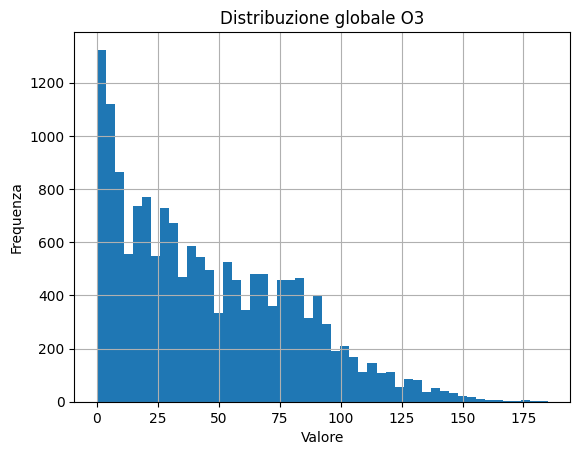

In [349]:
fig, o3_gm = plt.subplots()

df_O3_GM['valore'].hist(bins=50, ax = o3_gm)

o3_gm.set_title("Distribuzione globale O3")
o3_gm.set_xlabel("Valore")
o3_gm.set_ylabel("Frequenza")

plt.show()

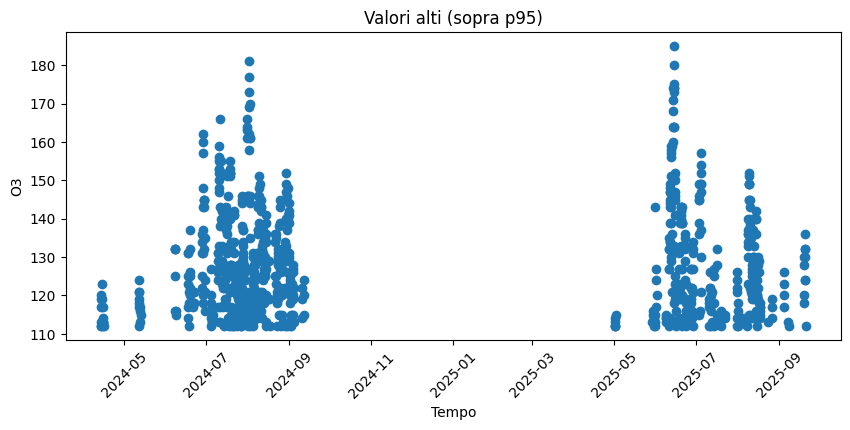

In [350]:
threshold = df_O3_GM['valore'].quantile(0.95)
df_high = df_O3_GM[df_O3_GM['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("O3")
plt.xticks(rotation=45)
plt.show()

Vedo che ci sono valori molto alti ma sono in estate, il che è coerente (link articolo)

Ci sono valori piuttosto alti ma decidiamo di tenerli perchè ci sembra che siano possibili.
Sono ricorrenti nei mesi invernali dove l'inquinamento aumenta quindi non sono così assurdi.

In [351]:
df_giorni.head()

,cod_staz,agente,data_inizio,data_fine,valore,um,flag_dupl,flag_pm10,giorno
23297,GIARDINI MARGHERITA,O3 (OZONO),2024-08-12 08:01:00+02:00,2024-08-12 09:00:00+02:00,83.0,ug/m3,False,False,2024-08-12
23298,GIARDINI MARGHERITA,PM10,2024-08-12 00:01:00+02:00,2024-08-13 00:00:00+02:00,13.0,ug/m3,False,True,2024-08-12
23301,GIARDINI MARGHERITA,O3 (OZONO),2024-08-13 05:01:00+02:00,2024-08-13 06:00:00+02:00,90.0,ug/m3,False,False,2024-08-13
23302,GIARDINI MARGHERITA,O3 (OZONO),2024-08-13 16:01:00+02:00,2024-08-13 17:00:00+02:00,135.0,ug/m3,False,False,2024-08-13
23306,GIARDINI MARGHERITA,O3 (OZONO),2024-08-14 11:01:00+02:00,2024-08-14 12:00:00+02:00,112.0,ug/m3,False,False,2024-08-14


Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [352]:
df_o3_daily = (
    df_giorni[df_giorni['agente'] == 'O3 (OZONO)']
    .groupby('giorno')['valore']
    .agg(
        media_O3='mean',
        mediana_O3='median',
        massimo_O3='max'
    )
    .reset_index()
)

df_o3_daily['media_O3'] = df_o3_daily['media_O3'].round(2)

In [353]:
df_o3_daily.head()

,giorno,media_O3,mediana_O3,massimo_O3
0,2024-01-01,19.00,18.0,42.0
1,2024-01-02,4.92,4.5,10.0
2,2024-01-03,7.04,4.0,26.0
3,2024-01-04,23.21,12.0,80.0
4,2024-01-05,5.33,4.0,13.0


In [354]:
df_NO2_GM = df_giorni.loc[(df_giorni['agente'] == 'NO2 (BIOSSIDO DI AZOTO)'), :]

df_NO2_GM['data_inizio'] = pd.to_datetime(df_NO2_GM['data_inizio'])
df_NO2_GM['giorno'] = df_NO2_GM['data_inizio'].dt.date
df_NO2_GM['ora'] = df_NO2_GM['data_inizio'].dt.hour

# conteggio ore per giorno
count_per_day = df_NO2_GM.groupby('giorno')['ora'].nunique()

# giorni completi (24 ore)
giorni_completi = count_per_day[count_per_day == 24].index

# giorni incompleti
giorni_incompleti = count_per_day[count_per_day != 24]

print(giorni_incompleti.head())

giorno
2024-01-17    23
2024-02-14    23
2024-03-03    16
2024-03-31    23
2024-04-08    22
Name: ora, dtype: int64


Dato che il numero di informazioni è comunque vicino a 24, decidiamo di tenerli e di trattarli come i giorni in cui abbiamo una misura per ora

Decidiamo di tenere anche il 3/03

In [355]:
# check se ci sono duplicati di giorno e ora
duplicati = df_NO2_GM.groupby(['giorno', 'ora']).size()
len(duplicati[duplicati > 1])

3

In [356]:
df_NO2_GM['giorno'] = pd.to_datetime(df_NO2_GM['giorno'] )

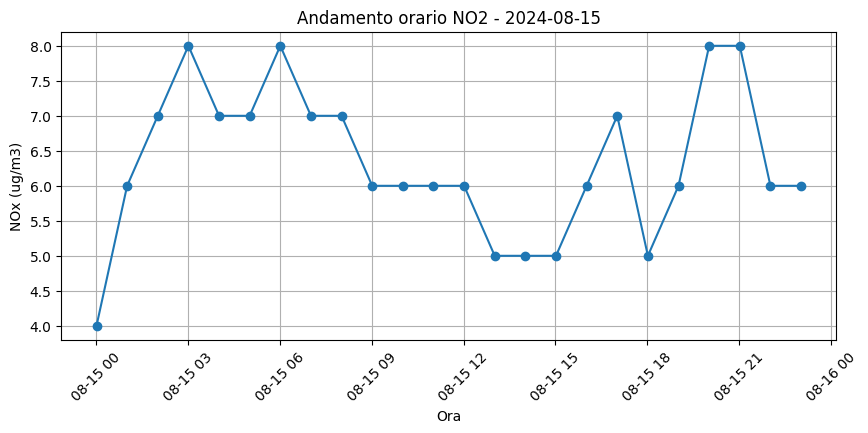

In [357]:
giorno = '2024-08-15'

df_day = df_NO2_GM.loc[df_NO2_GM['giorno'] == giorno, :]
df_day = df_day.sort_values('data_inizio')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df_day['data_inizio'], df_day['valore'], marker='o')
plt.title(f"Andamento orario NO2 - {giorno}")
plt.xlabel("Ora")
plt.ylabel("NOx (ug/m3)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [358]:
# check degli outliers con .describe
df_NO2_GM['valore'].describe()

count    16336.000000
mean        14.797564
std         10.848388
min          0.000000
25%          7.000000
50%         12.000000
75%         20.000000
max        126.000000
Name: valore, dtype: float64

In [359]:
(df_NO2_GM['valore'] == 0).sum()

np.int64(7)

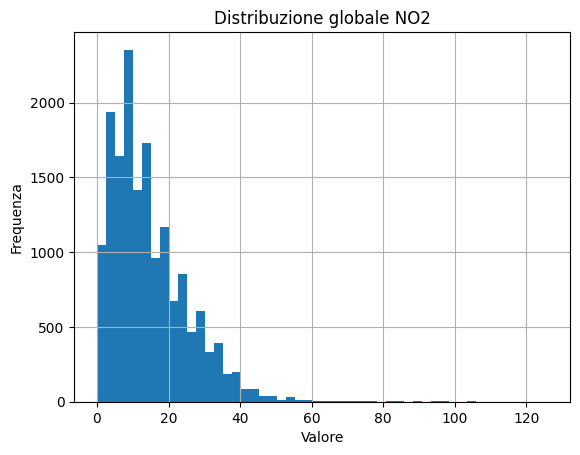

In [360]:
fig, no2_gm = plt.subplots()
df_NO2_GM['valore'].hist(bins=50, ax=no2_gm)

no2_gm.set_title("Distribuzione globale NO2")
no2_gm.set_xlabel("Valore")
no2_gm.set_ylabel("Frequenza")

plt.show()

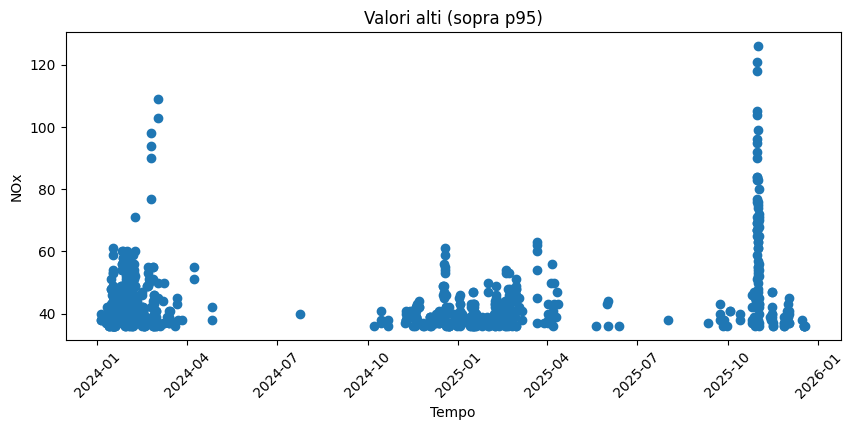

In [361]:
threshold = df_NO2_GM['valore'].quantile(0.95)
df_high = df_NO2_GM[df_NO2_GM['valore'] > threshold]

plt.figure(figsize=(10,4))
plt.scatter(df_high['data_inizio'], df_high['valore'])
plt.title("Valori alti (sopra p95)")
plt.xlabel("Tempo")
plt.ylabel("NOx")
plt.xticks(rotation=45)
plt.show()


Creo un df con solo le aggregate, poi droppo le originali tengo il df aggregato

In [362]:
df_no2_daily = (
    df_giorni[df_giorni['agente'] == 'NO2 (BIOSSIDO DI AZOTO)']
    .groupby('giorno')['valore']
    .agg(
        media_NO2='mean',
        mediana_NO2='median',
        massimo_NO2='max'
    )
    .reset_index()
)

df_no2_daily['media_NO2'] = df_no2_daily['media_NO2'].round(2)

In [363]:
df_no2_daily.head()

,giorno,media_NO2,mediana_NO2,massimo_NO2
0,2024-01-01,17.12,18.0,27.0
1,2024-01-02,23.62,25.0,33.0
2,2024-01-03,26.58,25.5,34.0
3,2024-01-04,23.42,27.0,40.0
4,2024-01-05,27.42,27.0,38.0


#### Unisco tutti i df

In [364]:
df_aggregato = df_giorni.copy()

In [365]:
# tengo solo le righe con PM10

lista_agenti = ['O3 (OZONO)', 'NO2 (BIOSSIDO DI AZOTO)']

for age in lista_agenti:
    df_aggregato = df_aggregato.drop(df_aggregato[df_aggregato['agente'] == age].index)

In [366]:
# tolgo le colonne inutili

df_aggregato = df_aggregato.drop(['data_inizio', 'data_fine', 'um', 'flag_dupl', 'flag_pm10'], axis=1)

In [367]:
df_aggregato['agente'].value_counts()

agente
PM10     692
PM2.5    685
Name: count, dtype: int64

In [368]:
df_wide_pm10 = (
    df_aggregato[df_aggregato['agente'].isin(['PM10'])]
    .groupby(['giorno', 'agente'])['valore']
    .mean()
    .unstack()
)

df_wide_pm10 = df_wide_pm10.reset_index()

df_wide_pm10.shape

(692, 2)

In [369]:
df_wide_pm25 = (
    df_aggregato[df_aggregato['agente'].isin(['PM2.5'])]
    .groupby(['giorno', 'agente'])['valore']
    .mean()
    .unstack()
)

df_wide_pm25 = df_wide_pm25.reset_index()

df_wide_pm25.shape

(678, 2)

In [370]:
# faccio il merge con gli altri df

df_merge_GM = df_wide_pm10.merge(df_o3_daily, how = 'left', on = 'giorno')
df_merge_GM = df_merge_GM.merge(df_wide_pm25, how = 'left', on = 'giorno')
df_merge_GM = df_merge_GM.merge(df_no2_daily, how='left', on = 'giorno')

df_merge_GM.shape

(692, 9)

In [371]:
df_merge_GM.isna().sum()

giorno          0
PM10            0
media_O3        6
mediana_O3      6
massimo_O3      6
PM2.5          14
media_NO2       4
mediana_NO2     4
massimo_NO2     4
dtype: int64

In [372]:
df_merge_GM.head()

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2
0,2024-01-01,20.0,19.00,18.0,42.0,20.0,17.12,18.0,27.0
1,2024-01-02,21.0,4.92,4.5,10.0,20.0,23.62,25.0,33.0
2,2024-01-03,28.0,7.04,4.0,26.0,26.0,26.58,25.5,34.0
3,2024-01-04,21.0,23.21,12.0,80.0,18.0,23.42,27.0,40.0
4,2024-01-05,39.0,5.33,4.0,13.0,37.0,27.42,27.0,38.0


### DF FINALI

#### NA (vengono trattadi nel code imputazione_missing)

In [373]:
miss = pd.concat([
    df_merge_SF.isna().sum(),
    df_merge_GM.isna().sum(),
    df_merge_VC.isna().sum(),
    ], axis=1)

miss.columns = ['SF', 'GM', 'VC']

print(miss)

                SF    GM    VC
giorno         0.0   0.0   0.0
PM10           0.0   0.0   0.0
PM2.5         26.0  14.0   NaN
media_CO      23.0   NaN   NaN
mediana_CO    23.0   NaN   NaN
massimo_CO    23.0   NaN   NaN
media_NOX      6.0   NaN   NaN
mediana_NOX    6.0   NaN   NaN
massimo_NOX    6.0   NaN   NaN
media_NO2     13.0   4.0  12.0
mediana_NO2   13.0   4.0  12.0
massimo_NO2   13.0   4.0  12.0
media_NO      19.0   NaN   NaN
mediana_NO    19.0   NaN   NaN
massimo_NO    19.0   NaN   NaN
media_C6H6    53.0   NaN   NaN
mediana_C6H6  53.0   NaN   NaN
massimo_C6H6  53.0   NaN   NaN
media_O3       NaN   6.0   7.0
mediana_O3     NaN   6.0   7.0
massimo_O3     NaN   6.0   7.0


In [ ]:
df_merge_VC

,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2
0,2024-01-01,21.0,10.92,7.0,37.0,20.00,20.5,26.0
1,2024-01-02,21.0,2.46,1.5,8.0,23.29,24.0,31.0
2,2024-01-03,28.0,5.50,1.0,27.0,26.67,26.0,32.0
3,2024-01-04,25.0,13.33,3.0,60.0,29.46,28.5,47.0
4,2024-01-05,39.0,2.17,0.5,12.0,29.38,29.5,40.0
5,2024-01-06,15.0,21.71,24.5,32.0,17.46,16.0,28.0
6,2024-01-07,11.0,31.62,33.0,46.0,16.96,17.0,24.0
7,2024-01-08,14.0,19.96,22.0,35.0,21.79,20.5,33.0
8,2024-01-09,27.0,17.50,14.5,47.0,24.42,22.5,43.0
9,2024-01-10,34.0,13.00,9.0,36.0,25.46,24.0,37.0


#### Salvo i dataset

In [374]:
df_merge_VC.to_parquet(os.path.join("..","data", "df_VC.parquet"), index=False)
df_merge_GM.to_parquet(os.path.join("..","data", "df_GM.parquet"), index=False)
df_merge_SF.to_parquet(os.path.join("..","data", "df_SF.parquet"), index=False)

#### Salvo anche i dataset specifici per agente che serviranno per imputare i missing

In [375]:
df_NO2_VC.to_parquet(os.path.join("..","data", "df_NO2_VC.parquet"), index=False)
df_NO2_GM.to_parquet(os.path.join("..","data", "df_NO2_GM.parquet"), index=False)
df_NO2_SF.to_parquet(os.path.join("..","data", "df_NO2_SF.parquet"), index=False)

In [376]:
df_O3_VC.to_parquet(os.path.join("..","data", "df_O3_VC.parquet"), index=False)
df_O3_GM.to_parquet(os.path.join("..","data", "df_O3_GM.parquet"), index=False)